In [2]:
from torchvision import models

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

len(model.features)

13

# Preprocessing Pipeline per Dataset IAM e RIMES

## Panoramica

Questo notebook implementa pipeline di preprocessing per due dataset di scrittura a mano:
- **IAM Handwriting Database**: immagini complete di form scritti a mano
- **RIMES**: singole linee di testo scritto a mano

L'obiettivo è normalizzare le immagini a dimensioni fisse mantenendo l'aspect ratio e la qualità visiva in grayscale.

In [1]:
import cv2
import os
import shutil
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from collections import defaultdict
import multiprocessing

# ==================== CONFIGURAZIONE ====================
TARGET_SIZE = 448
NUM_WORKERS = min(8, multiprocessing.cpu_count())
LINE_HEIGHT = 32
LINES_PER_BATCH = TARGET_SIZE // LINE_HEIGHT - 9 # 448 // 32 - 9 = 5

IAM_INPUT    = "../datasets/IAM/data"
IAM_OUTPUT   = "../datasets/processed-handwritten/iam_processed"
RIMES_INPUT  = "../datasets/RIMES/Handwritten2Text Training Dataset/Images"
RIMES_OUTPUT = "../datasets/processed-handwritten/rimes_processed"

## Funzioni Comuni

### 1. Binarizzazione di Otsu

La funzione `apply_threshold` converte l'immagine in grayscale e applica la binarizzazione di Otsu, ritornando sia l'immagine in grayscale che quella binarizzata.

**Formula di Otsu:**

Trova la soglia ottimale $t^*$ che massimizza la varianza tra classi:

$$
t^* = \arg\max_t \sigma_B^2(t)
$$

dove:

$$
\sigma_B^2(t) = \omega_0(t) \omega_1(t) [\mu_0(t) - \mu_1(t)]^2
$$

- $\omega_0(t)$: probabilità classe background (pixel > t)
- $\omega_1(t)$: probabilità classe foreground (pixel ≤ t)
- $\mu_0(t)$, $\mu_1(t)$: medie delle due classi

**Output:** Immagine binaria dove testo = nero (0), sfondo = bianco (255)

In [2]:
def apply_threshold(image):
    """Otsu's binarization - ritorna sia gray che binary"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return gray, binary

### 2. Rimozione Colonne Nere (Sinistra)

La funzione `compute_left_black_columns_crop` identifica e rimuove le colonne iniziali a sinistra che contengono una percentuale elevata di pixel neri.

**Calcolo del rapporto nero per colonna:**

Per ogni colonna $j$:

$$
r_j = \frac{\sum_{i=1}^{h} \mathbb{1}[I(i,j) = 0]}{h}
$$

Trova la prima colonna valida:

$$
j^* = \min\{j : r_j \leq \tau\}, \quad \tau = 0.5
$$

**Scopo:** Rimuove margini neri a sinistra causati da scansioni o artefatti.

In [3]:
def compute_left_black_columns_crop(binary_image, black_ratio_threshold=0.5):
    """
    Calcola l'indice della prima colonna valida da mantenere
    """
    h, w = binary_image.shape
    black_pixels_per_col = np.sum(binary_image == 0, axis=0)
    black_ratio = black_pixels_per_col / h
    
    valid_cols = np.where(black_ratio <= black_ratio_threshold)[0]
    
    if len(valid_cols) == 0:
        return 0
    
    return valid_cols[0]

### 3. Rimozione Righe Nere (Top/Bottom)

La funzione `compute_top_bottom_black_rows_crop` identifica e rimuove le righe in alto e in basso che contengono una percentuale elevata di pixel neri.

**Calcolo del rapporto nero per riga:**

Per ogni riga $i$:

$$
r_i = \frac{\sum_{j=1}^{w} \mathbb{1}[I(i,j) = 0]}{w}
$$

Trova prima e ultima riga valida:

$$
i_{\text{start}} = \min\{i : r_i \leq \tau\}, \quad i_{\text{end}} = \max\{i : r_i \leq \tau\}
$$

In [4]:
def compute_top_bottom_black_rows_crop(binary_image, black_ratio_threshold=0.5):
    """
    Calcola gli indici delle righe valide da mantenere (top e bottom)
    Ritorna tuple (first_valid_row, last_valid_row)
    """
    h, w = binary_image.shape
    black_pixels_per_row = np.sum(binary_image == 0, axis=1)
    black_ratio = black_pixels_per_row / w
    
    valid_rows = np.where(black_ratio <= black_ratio_threshold)[0]
    
    if len(valid_rows) == 0:
        return 0, h
    
    return valid_rows[0], valid_rows[-1] + 1

### 4. Tight Crop

La funzione `compute_tight_crop_coords` calcola le coordinate ottimali per croppare l'immagine eliminando spazi bianchi eccessivi mantenendo il contenuto testuale.

**Algoritmo:**

#### 4.1 Inversione

$I_{\text{inv}} = 255 - I_{\text{bin}}$

Il testo diventa bianco (255) e lo sfondo nero (0) per facilitare il conteggio dei pixel di contenuto.

#### 4.2 Somme Proiettate (Proiezioni Assiali)

Per ogni riga $i$ contiamo quanti pixel bianchi (testo) contiene:
$$
S_{\text{row}}(i) = \sum_{j=1}^{w} \mathbb{1}[I_{\text{inv}}(i,j) > 0]
$$

Per ogni colonna $j$ contiamo quanti pixel bianchi (testo) contiene:
$$
S_{\text{col}}(j) = \sum_{i=1}^{h} \mathbb{1}[I_{\text{inv}}(i,j) > 0]
$$

Queste proiezioni creano "profili" che indicano dove si concentra il contenuto testuale.

#### 4.3 Soglie Adattive

Le soglie determinano il numero minimo di pixel di testo necessari perché una riga/colonna sia considerata "contenente testo significativo".

**Per le righe:**
$$
\tau_{\text{row}} = \max(10, \lfloor 0.018 \cdot w \rfloor)
$$

**Per le colonne:**
$$
\tau_{\text{col}} = \max(10, \lfloor 0.018 \cdot h \rfloor)
$$

**Spiegazione dei parametri:**

- **`0.018` (1.8%)**: Questa percentuale rappresenta la soglia minima di "densità di inchiostro" necessaria. Una riga è considerata contenente testo se almeno l'1.8% dei suoi pixel è inchiostro. Questo valore è stato calibrato empiricamente per:
  - Essere abbastanza basso da catturare linee con scrittura sottile o poco densa
  - Essere abbastanza alto da ignorare artefatti, rumore di scansione o piccoli puntini isolati
  - Funzionare bene con diversi stili di scrittura (corsivo vs stampatello)

- **`10` (valore minimo assoluto)**: Garantisce che anche su immagini molto piccole (es. 200×100 pixel) la soglia non diventi troppo bassa. Esempi:
  - Immagine 100×50: $\lfloor 0.018 \cdot 100 \rfloor = 1$ → viene usato 10
  - Immagine 1000×800: $\lfloor 0.018 \cdot 1000 \rfloor = 18$ → viene usato 18
  
  Questo previene falsi positivi da rumore digitale su immagini di dimensioni ridotte.

#### 4.4 Calcolo Bounding Box

Troviamo la prima e l'ultima riga che contengono testo significativo:

$$
y_1 = \min\{i : S_{\text{row}}(i) > \tau_{\text{row}}\}
$$

$$
y_2 = \max\{i : S_{\text{row}}(i) > \tau_{\text{row}}\}
$$

Analogamente per le colonne, troviamo la prima e l'ultima colonna con testo:

$$
x_1 = \min\{j : S_{\text{col}}(j) > \tau_{\text{col}}\}
$$

$$
x_2 = \max\{j : S_{\text{col}}(j) > \tau_{\text{col}}\}
$$

Questo definisce il rettangolo minimale $(x_1, y_1, x_2, y_2)$ che racchiude tutto il contenuto testuale.

#### 4.5 Trim Aggressivo Interno

Per eliminare residui di linee guida (tipiche nei formato IAM), applichiamo un trim interno di 3 pixel:

$$
y_1' = \min(y_1 + 3, y_2 - 1)
$$

$$
y_2' = \max(y_2 - 3, y_1' + 1)
$$

Questo rimuove eventuali bordi di linee orizzontali senza intaccare il testo principale. I controlli $\min$ e $\max$ garantiscono che la regione risultante non collassi.

#### 4.6 Padding Esterno

Infine aggiungiamo un margine di 5 pixel su tutti i lati per evitare che il testo tocchi i bordi:

$$
y_{\text{final}} = [\max(0, y_1' - 5), \min(h, y_2' + 5)]
$$

$$
x_{\text{final}} = [\max(0, x_1 - 5), \min(w, x_2 + 5)]
$$

**Output:** Coordinate $(y_1, y_2, x_1, x_2)$ che definiscono il crop ottimale.

In [5]:
def compute_tight_crop_coords(binary_image, padding=5, min_pixel_ratio=0.018):
    """
    Calcola le coordinate di crop aggressive, ritorna (y1, y2, x1, x2)
    """
    binary_inv = 255 - binary_image
    h, w = binary_image.shape

    min_row_threshold = max(10, int(w * min_pixel_ratio))
    min_col_threshold = max(10, int(h * min_pixel_ratio))

    row_sums = np.sum(binary_inv > 0, axis=1)
    col_sums = np.sum(binary_inv > 0, axis=0)

    text_rows = np.where(row_sums > min_row_threshold)[0]
    text_cols = np.where(col_sums > min_col_threshold)[0]

    if len(text_rows) == 0 or len(text_cols) == 0:
        return None

    y1, y2 = text_rows[0], text_rows[-1]
    x1, x2 = text_cols[0], text_cols[-1]

    # Trim aggiuntivo
    extra_trim = 3
    y1 = min(y1 + extra_trim, y2 - 1)
    y2 = max(y2 - extra_trim, y1 + 1)

    # Applica padding
    y1 = max(0, y1 - padding)
    y2 = min(h, y2 + padding)
    x1 = max(0, x1 - padding)
    x2 = min(w, x2 + padding)

    return (y1, y2, x1, x2)

### 5. Resize to Square

La funzione `resize_to_square` normalizza l'immagine a dimensioni quadrate mantenendo l'aspect ratio originale.

**Algoritmo:**

1. **Canvas quadrato:** Crea un canvas bianco di lato $s = \max(h, w)$

2. **Centratura:**
   $$
   \text{offset}_y = \left\lfloor \frac{s - h}{2} \right\rfloor, \quad \text{offset}_x = \left\lfloor \frac{s - w}{2} \right\rfloor
   $$

3. **Resize finale:** Da $s \times s$ a $448 \times 448$ con interpolazione INTER_AREA (media dei pixel)

**Aspect ratio preservato:** L'immagine non viene distorta, solo ridimensionata proporzionalmente.

In [6]:
def resize_to_square(image, size=TARGET_SIZE):
    """Resize mantenendo aspect ratio in canvas quadrato - funziona con grayscale"""
    h, w = image.shape
    side = max(h, w)

    square = np.full((side, side), 255, dtype=np.uint8)
    y_off, x_off = (side - h) // 2, (side - w) // 2
    square[y_off:y_off + h, x_off:x_off + w] = image

    return cv2.resize(square, (size, size), interpolation=cv2.INTER_AREA)

In [7]:
def visualize_samples(output_folder, filename, n_samples=18, figsize=(25, 30)):
    """Visualizza campioni da diverse cartelle"""
    sample_folders = sorted(os.listdir(output_folder))[:n_samples]

    n_cols = 3
    n_rows = (n_samples + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_samples > 1 else [axes]

    for idx, folder in enumerate(sample_folders):
        folder_path = os.path.join(output_folder, folder)
        images = [f for f in os.listdir(folder_path) if f.endswith(".png")]

        if images:
            print(images[0])
            img = cv2.imread(
                os.path.join(folder_path, images[0]),
                cv2.IMREAD_GRAYSCALE
            )
            axes[idx].imshow(img, cmap="gray")
            axes[idx].set_title(f"Writer {folder}\nSize: {img.shape}")
            axes[idx].axis("off")

    plt.tight_layout()
    plt.savefig('images/' + filename, dpi=150, bbox_inches="tight")
    plt.show()

## Pipeline IAM

### Struttura Dataset
```
IAM/data/
├── writer_001/
│   ├── image_001.png
│   ├── image_002.png
│   └── ...
└── writer_002/
    └── ...
```

### Step 1: Estrazione Regione Handwritten

La funzione `extract_handwritten_region_iam` isola il testo scritto a mano tra le linee guida del form IAM.

#### 1.1 Rilevamento Linee Guida

Utilizza operazioni morfologiche per rilevare linee orizzontali:

**Morfologia:**

$$
\text{Opening}(I, K) = \text{Dilate}(\text{Erode}(I, K), K)
$$

con kernel orizzontale $K \in \mathbb{R}^{1 \times k_w}$ dove $k_w = \max(30, \lfloor w/15 \rfloor)$.

**Effetto:** Rimuove testo verticale, mantiene solo linee orizzontali lunghe.

#### 1.2 Filtraggio Contorni

Per ogni contorno trovato, calcola bounding box $(x, y, w_c, h_c)$ e area $A$.

Linea valida se:
$$
\begin{cases}
w_c > 0.3w \\
h_c < 20 \\
A > 100
\end{cases}
$$

#### 1.3 Selezione Regione

**Caso ideale (≥3 linee):**
$$
y_{\text{start}} = y_{\text{bottom}}^{(2)} + 8
$$
$$
y_{\text{end}} = y_{\text{top}}^{(3)} - 8
$$

dove $(2)$ è la seconda linea dall'alto, $(3)$ è la terza (prima dal basso).

**Fallback:** Se non trova linee sufficienti:
$$
y_{\text{start}} = \lfloor 0.22h \rfloor, \quad y_{\text{end}} = \lfloor 0.85h \rfloor
$$

#### 1.4 Estrazione

Ritorna sia la regione in grayscale che quella binarizzata per il processing successivo.

In [8]:
def extract_handwritten_region_iam(image_path):
    """
    Estrae handwriting tra 2ª linea (dall'alto) e 3ª linea (1ª dal basso)
    Ritorna tuple (gray_region, binary_region) per processing successivo
    """
    image = cv2.imread(image_path)
    if image is None:
        return None, None

    gray, binary = apply_threshold(image)
    h, w = binary.shape
    thresh_inv = 255 - binary

    # Rileva linee orizzontali
    kernel_width = max(30, w // 15)
    kernel = np.ones((1, kernel_width), np.uint8)
    black_lines = cv2.morphologyEx(
        thresh_inv, cv2.MORPH_OPEN, kernel, iterations=2
    )

    contours, _ = cv2.findContours(
        black_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    valid_lines = []
    for c in contours:
        x, y, cw, ch = cv2.boundingRect(c)
        area = cv2.contourArea(c)

        if cw > w * 0.3 and ch < 20 and area > 100:
            valid_lines.append({
                "y_top": y,
                "y_bottom": y + ch,
                "y_center": y + ch // 2,
                "height": ch,
                "width": cw
            })

    valid_lines = sorted(valid_lines, key=lambda l: l["y_center"])

    if len(valid_lines) >= 3:
        second_line = valid_lines[1]
        y_start = second_line["y_bottom"] + 8

        third_line = valid_lines[2]
        y_end = third_line["y_top"] - 8

    elif len(valid_lines) == 2:
        y_start = valid_lines[0]["y_bottom"] + 8
        y_end = valid_lines[1]["y_top"] - 8

    else:
        row_density = np.sum(thresh_inv > 0, axis=1)
        from scipy.ndimage import uniform_filter1d
        smoothed = uniform_filter1d(row_density, size=5)

        threshold_line = np.percentile(smoothed, 95)
        potential_lines = np.where(smoothed > threshold_line)[0]

        if len(potential_lines) > 0:
            lines = []
            current_start = potential_lines[0]

            for i in range(1, len(potential_lines)):
                if potential_lines[i] - potential_lines[i - 1] > 5:
                    lines.append((current_start, potential_lines[i - 1]))
                    current_start = potential_lines[i]
            lines.append((current_start, potential_lines[-1]))

            if len(lines) >= 3:
                y_start = lines[1][1] + 8
                y_end = lines[2][0] - 8
            elif len(lines) == 2:
                y_start = lines[0][1] + 8
                y_end = lines[1][0] - 8
            else:
                y_start = int(h * 0.22)
                y_end = int(h * 0.85)
        else:
            y_start = int(h * 0.22)
            y_end = int(h * 0.85)

    if y_start >= y_end:
        y_start = int(h * 0.22)
        y_end = int(h * 0.85)

    y_start = max(0, y_start)
    y_end = min(h, y_end)

    extracted_gray = gray[y_start:y_end, :]
    extracted_binary = binary[y_start:y_end, :]

    if extracted_binary.size == 0 or extracted_binary.shape[0] < 30 or extracted_binary.shape[1] < 50:
        fallback_start = int(h * 0.22)
        fallback_end = int(h * 0.85)
        return gray[fallback_start:fallback_end, :], binary[fallback_start:fallback_end, :]

    return extracted_gray, extracted_binary

### Step 2: Processo Completo IAM

La funzione `process_iam_image` implementa la pipeline sequenziale completa:

**Pipeline sequenziale:**

1. **Estrazione regione:** Utilizza `extract_handwritten_region_iam` per isolare la zona di testo
   - Input: Immagine RGB completa
   - Output: `(gray_region, binary_region)`

2. **Rimozione colonne nere:** Calcola la prima colonna valida sulla binary e applica il crop su entrambe le immagini

3. **Tight crop:** Calcola le coordinate di crop sulla binary e applica sulla grayscale

4. **Resize to square:** Normalizza l'immagine finale a 448×448

**Output:** Immagine grayscale 448×448 con testo centrato e normalizzato.

🔄 Processing 1539 IAM images with 8 workers...


IAM: 100%|██████████| 1539/1539 [01:32<00:00, 16.59it/s]


✅ IAM Complete! Processed: 1539 | Skipped: 0

a05-044.png
a01-072x.png
a01-003.png
a01-007x.png
a01-007.png
a01-011.png


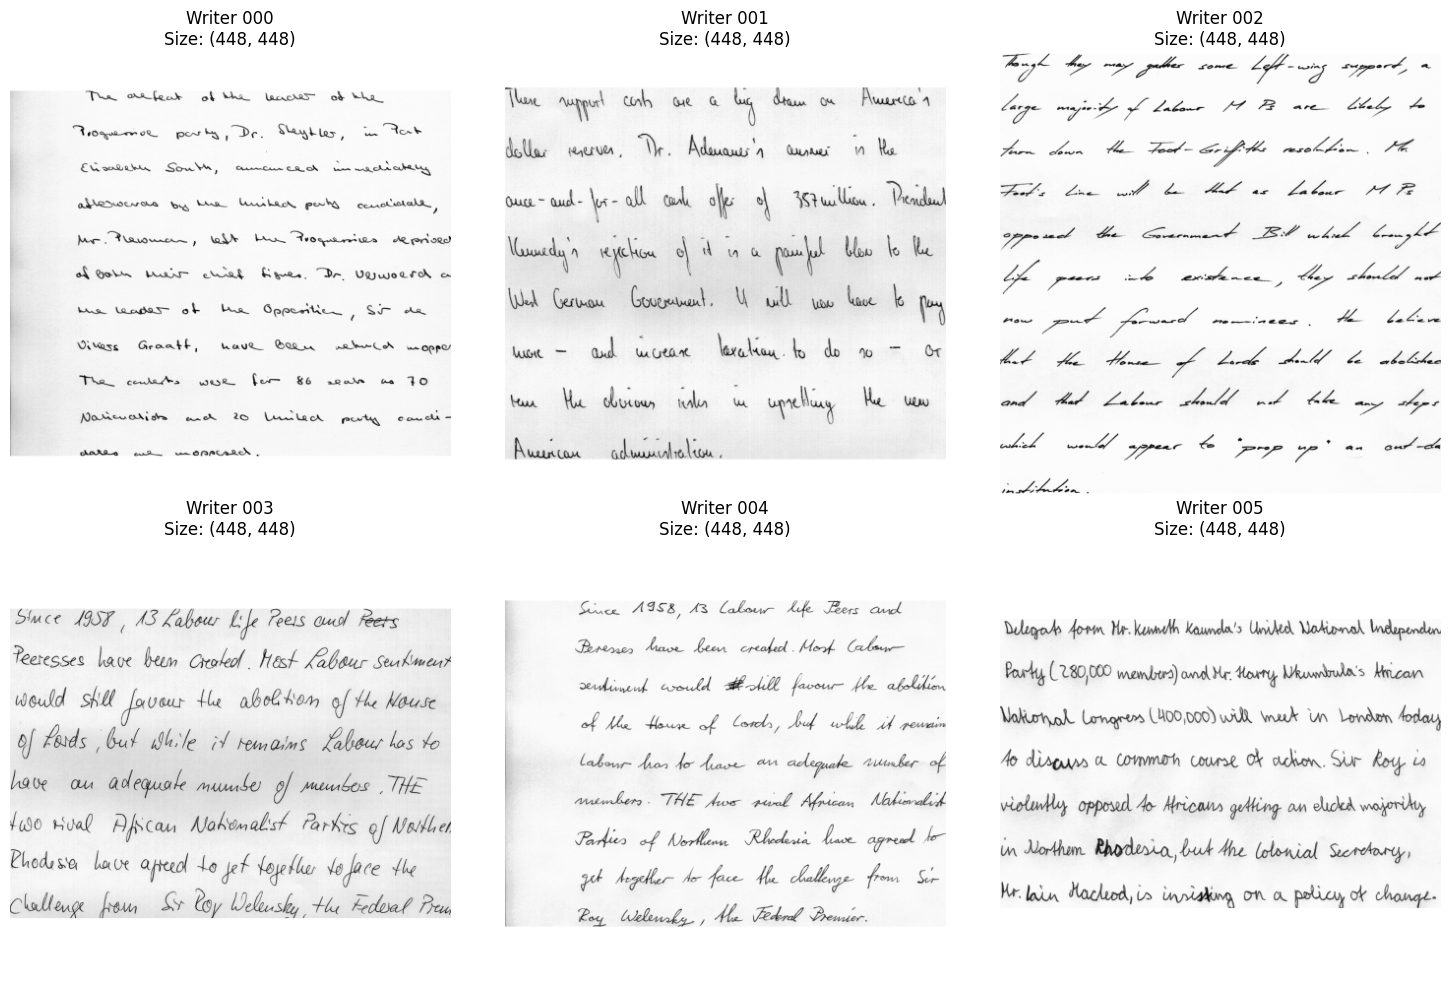

📊 Writers: 657 | Output: ../datasets/processed-handwritten/iam_processed



In [ ]:
def process_iam_image(args):
    """Processa singola immagine IAM applicando crop su grayscale"""
    image_path, output_path = args
    try:
        # Estrae regione handwritten (gray + binary)
        gray_region, binary_region = extract_handwritten_region_iam(image_path)
        
        if gray_region is None or binary_region is None or binary_region.size == 0:
            return False

        # Calcola crop colonne nere sulla binary
        first_valid_col = compute_left_black_columns_crop(
            binary_region, black_ratio_threshold=0.5
        )
        
        # Applica su entrambe
        gray_cleaned = gray_region[:, first_valid_col:]
        binary_cleaned = binary_region[:, first_valid_col:]

        # Calcola coordinate tight crop sulla binary
        crop_coords = compute_tight_crop_coords(
            binary_cleaned, padding=5, min_pixel_ratio=0.02
        )
        
        if crop_coords is None:
            return False
        
        y1, y2, x1, x2 = crop_coords
        
        # Applica crop sulla grayscale
        gray_cropped = gray_cleaned[y1:y2, x1:x2]
        
        if gray_cropped.size == 0:
            return False

        # Resize finale su grayscale
        final = resize_to_square(gray_cropped)
        cv2.imwrite(output_path, final)
        return True

    except Exception:
        return False

""" Pipeline IAM """

if os.path.exists(IAM_OUTPUT): shutil.rmtree(IAM_OUTPUT)  # elimina la cartella e tutto il contenuto
os.makedirs(IAM_OUTPUT)

tasks = []
for folder in sorted(os.listdir(IAM_INPUT)):
    folder_path = os.path.join(IAM_INPUT, folder)
    if not os.path.isdir(folder_path):
        continue

    output_subfolder = os.path.join(IAM_OUTPUT, folder)
    os.makedirs(output_subfolder, exist_ok=True)

    for img_name in os.listdir(folder_path):
        if img_name.endswith((".png", ".jpg", ".jpeg")):
            tasks.append((
                os.path.join(folder_path, img_name),
                os.path.join(
                    output_subfolder,
                    f"{Path(img_name).stem}.png"
                )
            ))

print(f"🔄 Processing {len(tasks)} IAM images with {NUM_WORKERS} workers...")

processed = skipped = 0
with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {
        executor.submit(process_iam_image, task): task
        for task in tasks
    }

    for future in tqdm(as_completed(futures), total=len(tasks), desc="IAM"):
        if future.result():
            processed += 1
        else:
            skipped += 1

print(f"✅ IAM Complete! Processed: {processed} | Skipped: {skipped}\n")

visualize_samples(IAM_OUTPUT, "iam_samples.png", n_samples=6, figsize=(15, 10))
print(f"📊 Writers: {len(os.listdir(IAM_OUTPUT))} | Output: {IAM_OUTPUT}\n")


## Pipeline RIMES

### Struttura Dataset
```
RIMES/Images/
├── line_001-writer_A-001.png
├── line_002-writer_A-002.png
├── line_003-writer_B-001.png
└── ...
```

### Parsing Writer ID

Il writer ID viene estratto dal nome file splittando per '-' e prendendo la prima parte del secondo elemento.

### Step 1: Preprocessing Singola Linea

La funzione `preprocess_rimes_line` processa ogni singola linea di testo.

#### 1.1 Binarizzazione

Applica Otsu threshold per ottenere sia grayscale che binary.

#### 1.2 Rimozione Righe Nere

Rimuove righe nere in alto e in basso utilizzando la soglia del 50%.

#### 1.3 Tight Crop

Calcola le coordinate di crop sulla binary e applica sulla grayscale.

#### 1.4 Resize Adattivo con Aspect Ratio

**Formule:**

- **Caso normale (linea corta):**
  $$
  w' = \left\lfloor w \cdot \frac{32}{h} \right\rfloor, \quad h' = 32
  $$

- **Caso linea lunga ($w' > 448$):**
  $$
  w' = 448, \quad h' = \left\lfloor h \cdot \frac{448}{w} \right\rfloor
  $$

**Aspect ratio preservato:**
$$
\frac{w'}{h'} = \frac{w}{h}
$$

#### 1.5 Padding e Centratura

Crea un canvas 32×448 bianco e centra verticalmente la linea ridimensionata:

**Offset verticale:**
$$
\text{offset}_y = \left\lfloor \frac{32 - h'}{2} \right\rfloor
$$

**Output:** Linea normalizzata 32×448 (altezza fissa, larghezza variabile con padding).

In [10]:
def preprocess_rimes_line(image, max_width=TARGET_SIZE * 2):
    """
    Preprocessa singola linea RIMES
    Restituisce lista di immagini croppate (splitta se troppo lunga)
    """
    # Ottieni sia gray che binary
    gray, binary = apply_threshold(image)
    
    # Rimuove righe nere in alto/basso
    first_row, last_row = compute_top_bottom_black_rows_crop(
        binary, black_ratio_threshold=0.5
    )
    gray_cleaned = gray[first_row:last_row, :]
    binary_cleaned = binary[first_row:last_row, :]
    
    # Calcola coordinate crop sulla binary
    crop_coords = compute_tight_crop_coords(binary_cleaned, padding=5)
    if crop_coords is None:
        return []
    
    y1, y2, x1, x2 = crop_coords
    gray_cropped = gray_cleaned[y1:y2, x1:x2]
    
    if gray_cropped.size == 0:
        return []
    
    # Split se troppo lunga
    if gray_cropped.shape[1] > max_width:
        mid = gray_cropped.shape[1] // 2
        return [gray_cropped[:, :mid], gray_cropped[:, mid:]]
    
    return [gray_cropped]


def resize_to_fixed_height(image, target_height, target_width):
    """
    Resize immagine ad altezza fissa mantenendo aspect ratio,
    poi padding per centrare
    """
    h, w = image.shape
    
    # Calcola nuova larghezza mantenendo aspect ratio
    new_w = int(w * target_height / h)
    
    # Se troppo larga, scala per farla entrare
    if new_w > target_width:
        new_w = target_width
        new_h = int(h * target_width / w)
    else:
        new_h = target_height
    
    # Resize
    resized = cv2.resize(
        image, 
        (new_w, new_h), 
        interpolation=cv2.INTER_AREA
    )
    
    # Crea canvas con altezza fissa
    canvas = np.full((target_height, target_width), 255, dtype=np.uint8)
    
    # Centra verticalmente
    y_offset = (target_height - new_h) // 2
    
    # Inserisci immagine
    canvas[y_offset:y_offset + new_h, :new_w] = resized
    
    return canvas

### Step 2: Creazione Batch

Le linee vengono raggruppate per writer e impilate verticalmente in batch da 14 linee ciascuno.

**Algoritmo:**

1. **Vertical stacking:**
   $$
   B = \begin{bmatrix}
   L_1 \\
   L_2 \\
   \vdots \\
   L_{14}
   \end{bmatrix} \in \mathbb{R}^{(14 \times 32) \times 448} = \mathbb{R}^{448 \times 448}
   $$

2. **Padding finale:** Se ci sono meno di 14 linee, il resto viene riempito con bianco (255).

**Output:** Immagine 448×448 contenente fino a 14 linee impilate verticalmente.

📂 Scanning RIMES dataset...


100%|██████████| 12111/12111 [00:00<00:00, 345500.53it/s]


✅ Found 1500 writers



RIMES writers: 100%|██████████| 1500/1500 [00:43<00:00, 34.57it/s]


✅ RIMES Complete! Writers: 1500 | Batches: 5046

batch_004.png
batch_063.png
batch_013.png
batch_632.png
batch_603.png
batch_608.png
batch_609.png
batch_615.png
batch_621.png
batch_624.png
batch_625.png
batch_627.png
batch_629.png
batch_630.png
batch_670.png
batch_635.png
batch_637.png
batch_641.png


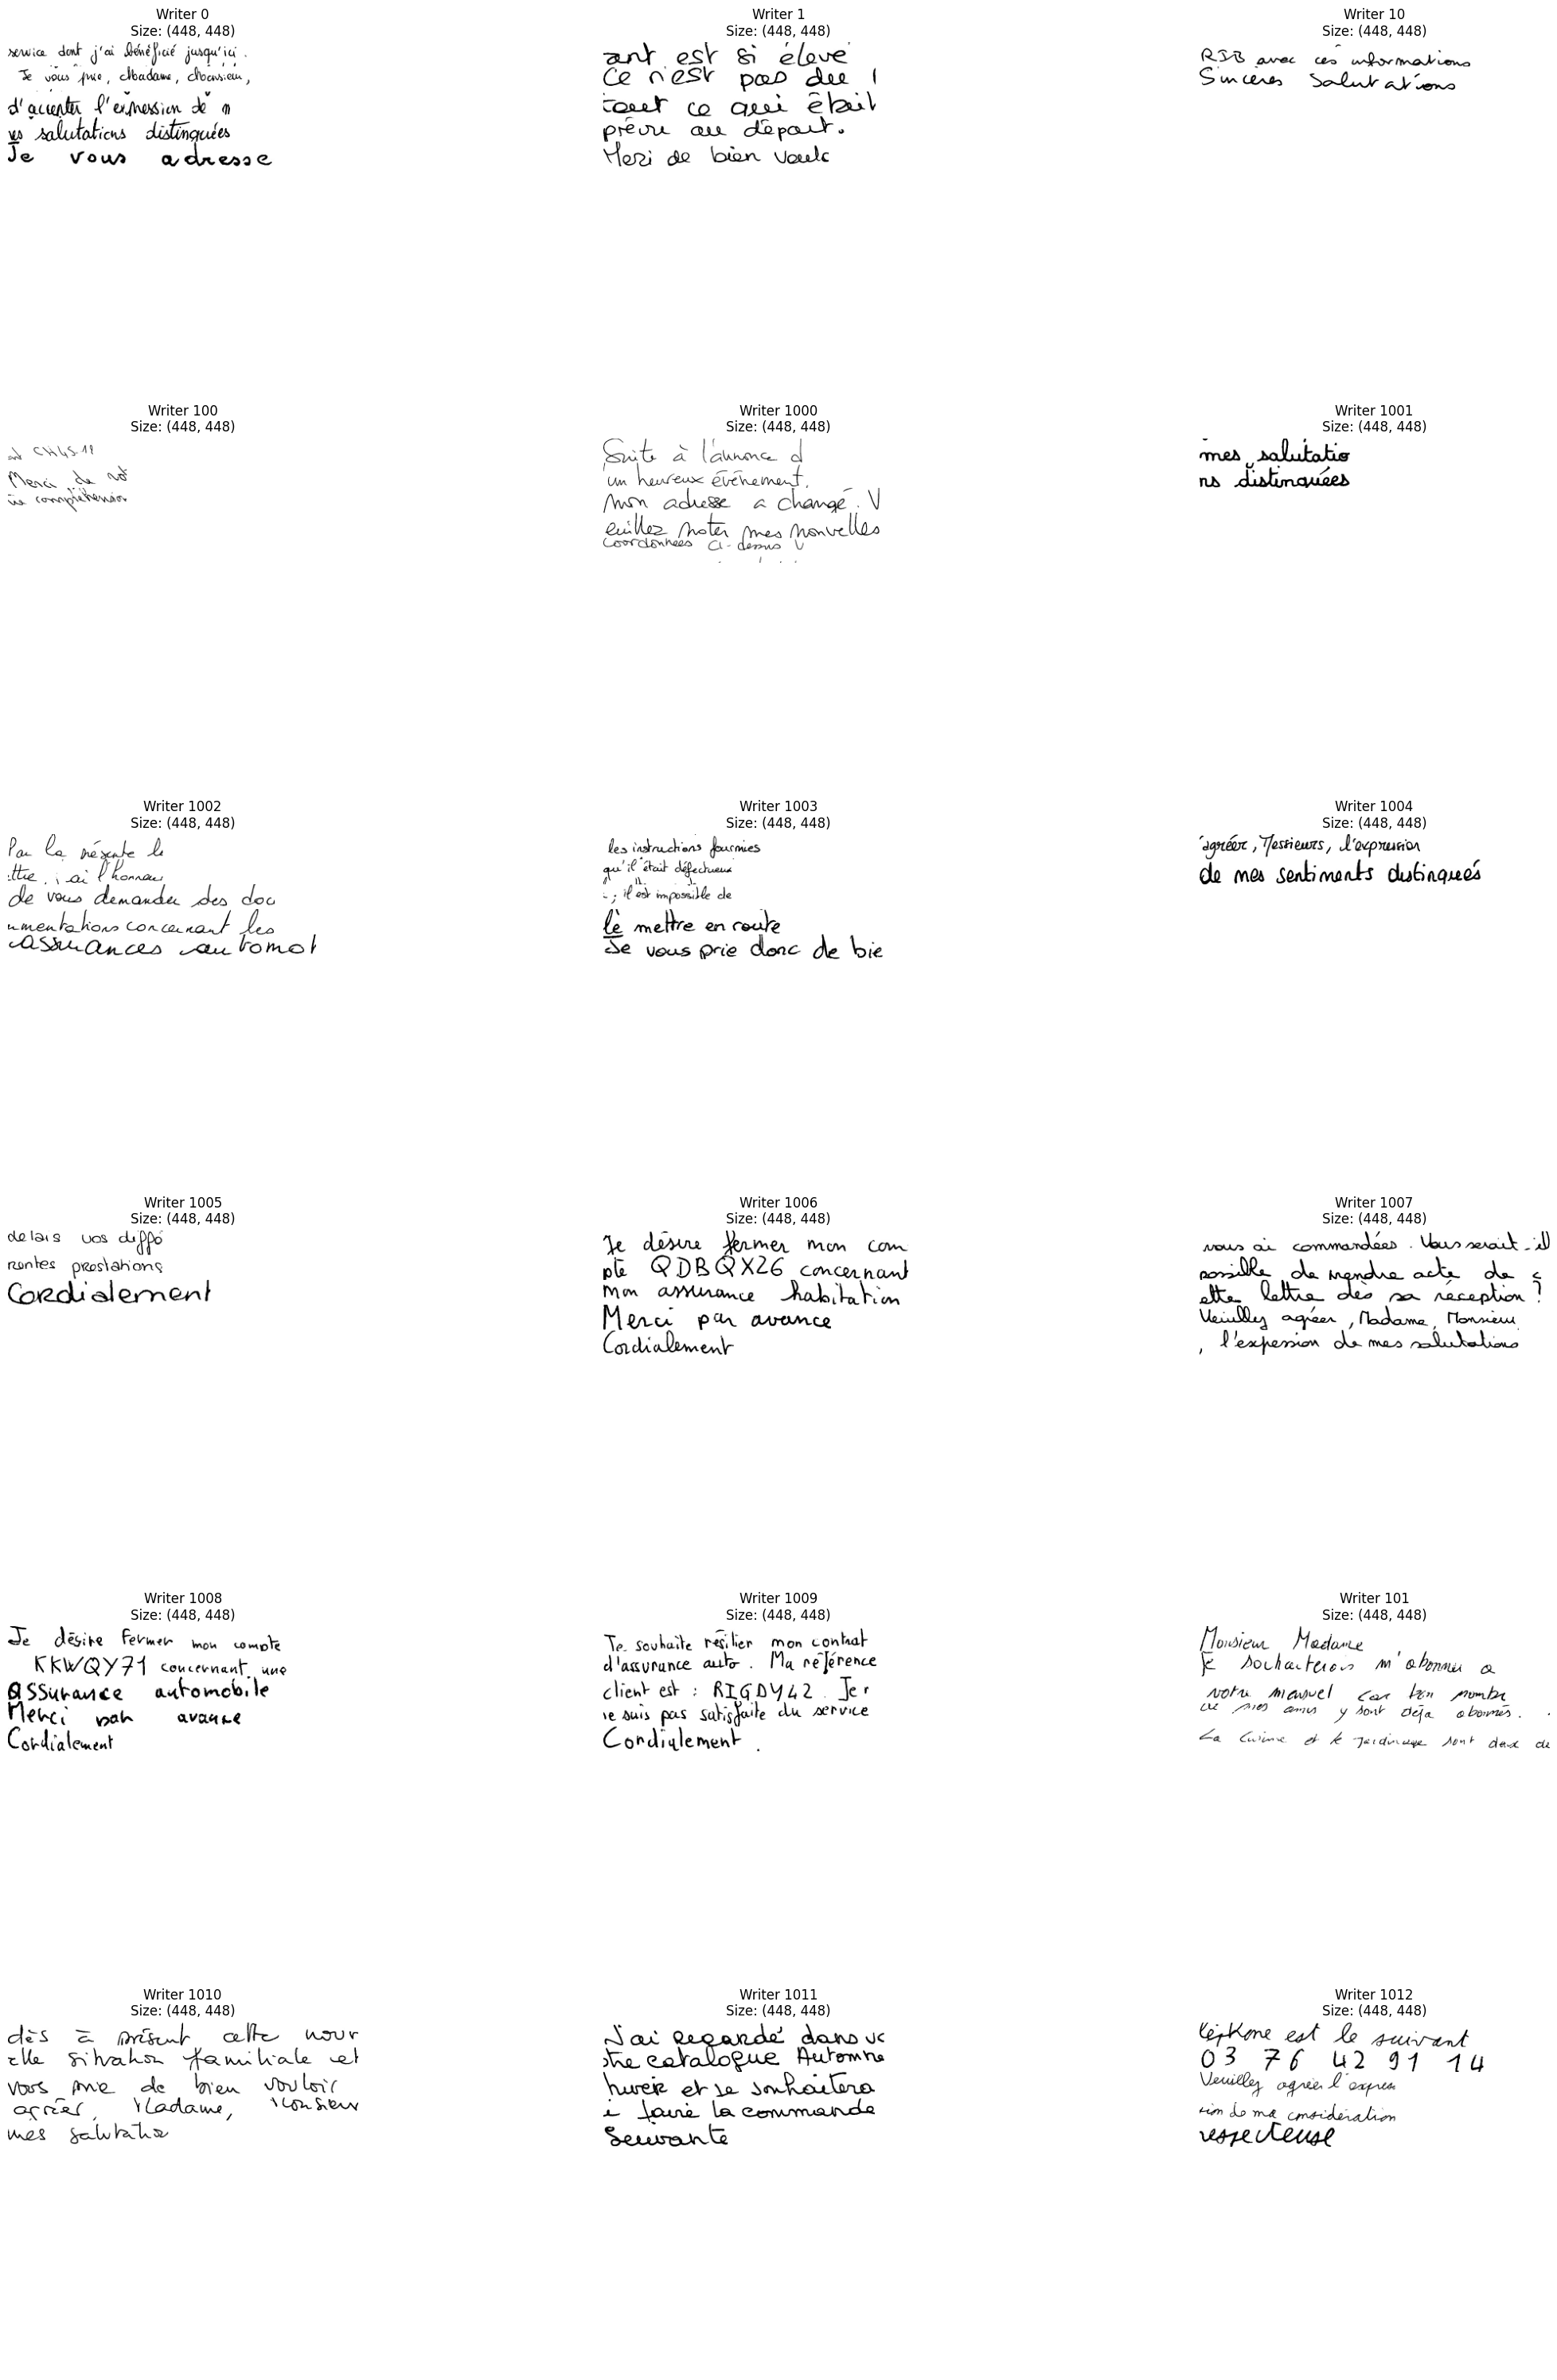

📊 Output: ../datasets/processed-handwritten/rimes_processed



In [11]:
"""Pipeline completa RIMES con altezza uniforme per author"""

if os.path.exists(RIMES_OUTPUT): shutil.rmtree(RIMES_OUTPUT)  # elimina la cartella e tutto il contenuto
os.makedirs(RIMES_OUTPUT)

# Raggruppa per writer
writer_images = defaultdict(list)
print("📂 Scanning RIMES dataset...")
for img_name in tqdm(sorted(os.listdir(RIMES_INPUT))):
    if not img_name.endswith(('.jpg', '.png', '.jpeg')):
        continue
    
    parts = img_name.split('-')
    if len(parts) < 2:
        continue
    
    writer_id = parts[1].split('_')[0]
    writer_images[writer_id].append(os.path.join(RIMES_INPUT, img_name))

print(f"✅ Found {len(writer_images)} writers\n")

# Processa per writer
total_batches = 0
for writer_id, image_paths in tqdm(writer_images.items(), desc="RIMES writers"):
    writer_folder = os.path.join(RIMES_OUTPUT, writer_id)
    os.makedirs(writer_folder, exist_ok=True)
    
    # Prima passata: preprocessa e trova altezza minima
    cropped_lines = []
    min_height = float('inf')
    
    for img_path in image_paths:
        img = cv2.imread(img_path)
        if img is not None:
            line_splits = preprocess_rimes_line(img)
            for line in line_splits:
                cropped_lines.append(line)
                min_height = min(min_height, line.shape[0])
    
    if not cropped_lines:
        continue
    
    # Assicurati che l'altezza sia ragionevole
    min_height = max(min_height, 20)
    min_height = min(min_height, LINE_HEIGHT)
    
    # Seconda passata: resize TUTTE le linee alla stessa altezza (quella minima)
    lines = []
    for cropped_line in cropped_lines:
        resized_line = resize_to_fixed_height(cropped_line, min_height, TARGET_SIZE)
        lines.append(resized_line)
    
    # Verifica che tutte le linee abbiano la stessa altezza
    assert all(line.shape[0] == min_height for line in lines), "Le linee non hanno tutte la stessa altezza!"
    
    # Crea batch - ora tutte le linee hanno la stessa altezza garantita
    for i in range(0, len(lines), LINES_PER_BATCH):
        batch_lines = lines[i:i + LINES_PER_BATCH]
        batch = np.vstack(batch_lines)
        
        canvas = np.full((TARGET_SIZE, TARGET_SIZE), 255, dtype=np.uint8)
        canvas[:batch.shape[0], :] = batch
        
        cv2.imwrite(
            os.path.join(writer_folder, f"batch_{total_batches:03d}.png"),
            canvas
        )
        total_batches += 1

print(f"✅ RIMES Complete! Writers: {len(writer_images)} | Batches: {total_batches}\n")

# Visualizza
visualize_samples(RIMES_OUTPUT, 'rimes_samples.png')
print(f"📊 Output: {RIMES_OUTPUT}\n")